In [2]:
from circuit_toolkit.plot_utils import saveallforms
import numpy as np
import pandas as pd

/n/home12/binxuwang/Github/circuit_toolkit/circuit_toolkit/GAN_invert_utils.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange, tqdm


In [5]:
%load_ext autoreload
%autoreload 2

In [6]:
import pandas as pd
from os.path import join
import torch
import torch as th
import torch.nn.functional as F
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
import os
from os.path import join
import torch
import torch as th
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.append("/n/home12/binxuwang/Github/DiffusionObjectRelation/PixArt-alpha")
from diffusion import IDDPM
from diffusion.data.builder import build_dataset, build_dataloader, set_data_root
from diffusion.model.builder import build_model
from diffusion.utils.misc import set_random_seed, read_config, init_random_seed, DebugUnderflowOverflow
sys.path.append("/n/home12/binxuwang/Github/DiffusionObjectRelation")
from utils.pixart_sampling_utils import pipeline_inference_custom, \
    PixArtAlphaPipeline_custom
from utils.pixart_utils import state_dict_convert
from utils.text_encoder_control_lib import RandomEmbeddingEncoder_wPosEmb
from utils.image_utils import pil_images_to_grid
from utils.attention_map_store_utils import replace_attn_processor, AttnProcessor2_0_Store, PixArtAttentionVisualizer_Store
from utils.cv2_eval_utils import find_classify_object_masks
from diffusers import AutoencoderKL, Transformer2DModel, PixArtAlphaPipeline, DPMSolverMultistepScheduler
from transformers import T5Tokenizer, T5EncoderModel

/n/home12/binxuwang/.conda/envs/torch2/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(
/n/home12/binxuwang/.conda/envs/torch2/lib/python3.10/site-packages/xformers/ops/fmha/flash.py:211: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_fwd")
/n/home12/binxuwang/.conda/envs/torch2/lib/python3.10/site-packages/xformers/ops/fmha/flash.py:344: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Pleas

In [8]:
from diffusion.model.nets.PixArt import get_2d_sincos_pos_embed

In [23]:
model_run_name = "objrel_rndembdposemb_DiT_B_pilot"

In [9]:
savedir = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/PixArt/results/objrel_rndembdposemb_DiT_B_pilot"

config = read_config(join(savedir, 'config.py'))

weight_dtype = torch.float32
if config.mixed_precision == "fp16": # accelerator.
    weight_dtype = torch.float16
elif config.mixed_precision == "bf16": # accelerator.
    weight_dtype = torch.bfloat16
    
image_size = config.image_size  # @param [256, 512, 1024]
latent_size = int(image_size) // 8
pred_sigma = getattr(config, 'pred_sigma', True)
learn_sigma = getattr(config, 'learn_sigma', True) and pred_sigma
model_kwargs={"window_block_indexes": config.window_block_indexes, "window_size": config.window_size,
                "use_rel_pos": config.use_rel_pos, "lewei_scale": config.lewei_scale, 'config':config,
                'model_max_length': config.model_max_length}
# train_diffusion = IDDPM(str(config.train_sampling_steps), learn_sigma=learn_sigma, pred_sigma=pred_sigma, snr=config.snr_loss)
model = build_model(config.model,
                config.grad_checkpointing,
                config.get('fp32_attention', False),
                input_size=latent_size,
                learn_sigma=learn_sigma,
                pred_sigma=pred_sigma,
                **model_kwargs).train()

transformer = Transformer2DModel(
        sample_size=image_size // 8,
        num_layers=len(model.blocks),
        attention_head_dim=model.blocks[0].hidden_size // model.num_heads,
        in_channels=model.in_channels,
        out_channels=model.out_channels,
        patch_size=model.patch_size,
        attention_bias=True,
        num_attention_heads=model.num_heads,
        cross_attention_dim=model.blocks[0].hidden_size,
        activation_fn="gelu-approximate",
        num_embeds_ada_norm=1000,
        norm_type="ada_norm_single",
        norm_elementwise_affine=False,
        norm_eps=1e-6,
        caption_channels=4096,
)
# state_dict = state_dict_convert(all_state_dict.pop("state_dict"))
transformer.load_state_dict(state_dict_convert(model.state_dict()))
pipeline = PixArtAlphaPipeline_custom.from_pretrained(
    "PixArt-alpha/PixArt-XL-2-512x512",
    transformer=transformer,
    tokenizer=None,
    text_encoder=None,
    torch_dtype=weight_dtype,
)

2026-01-30 01:15:55,091 - PixArt - WARNING - lewei scale: (1.0,), base size: 8


Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]

Expected types for transformer: (<class 'diffusers.models.transformers.pixart_transformer_2d.PixArtTransformer2DModel'>,), got <class 'diffusers.models.transformers.transformer_2d.Transformer2DModel'>.


In [10]:
ckptdir = join(savedir, "checkpoints")
ckpt = torch.load(join(ckptdir, "epoch_4000_step_160000.pth"))
pipeline.transformer.load_state_dict(state_dict_convert(ckpt['state_dict_ema']))

/tmp/ipykernel_2935540/1495998778.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(join(ckptdir, "epoch_4000_step_160000.pth"))


<All keys matched successfully>

In [11]:
text_feat_dir_old = '/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/PixArt/training_datasets/random_emd_dictionary/'
emb_data = th.load(join(text_feat_dir_old, "word_embedding_dict.pt"))
rndpos_encoder = RandomEmbeddingEncoder_wPosEmb(emb_data["embedding_dict"], 
                                              emb_data["input_ids2dict_ids"], 
                                              emb_data["dict_ids2input_ids"], 
                                              max_seq_len=20, embed_dim=4096,
                                              wpe_scale=1/6).to("cuda")

/tmp/ipykernel_2935540/1804778965.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  emb_data = th.load(join(text_feat_dir_old, "word_embedding_dict.pt"))


In [12]:
T5_path = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/PixArt/output/pretrained_models/t5_ckpts/t5-v1_1-xxl"
tokenizer = T5Tokenizer.from_pretrained(T5_path, )#subfolder="tokenizer")
# encoder = T5EncoderModel.from_pretrained(T5_path)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [13]:
pipeline.tokenizer = tokenizer
pipeline.text_encoder = rndpos_encoder
pipeline.to(device="cuda", dtype=weight_dtype);

In [14]:

def create_pipeline_from_config(config, tokenizer, text_encoder, weight_dtype):
    """Create the diffusion pipeline from config."""
    image_size = config.image_size
    latent_size = int(image_size) // 8
    pred_sigma = getattr(config, 'pred_sigma', True)
    learn_sigma = getattr(config, 'learn_sigma', True) and pred_sigma
    model_kwargs = {
        "window_block_indexes": config.window_block_indexes, 
        "window_size": config.window_size,
        "use_rel_pos": config.use_rel_pos, 
        "lewei_scale": config.lewei_scale, 
        'config': config,
        'model_max_length': config.model_max_length,
        'caption_channels': config.caption_channels,
    }
    
    model = build_model(
        config.model,
        config.grad_checkpointing,
        config.get('fp32_attention', False),
        input_size=latent_size,
        learn_sigma=learn_sigma,
        pred_sigma=pred_sigma,
        **model_kwargs
    ).train()
    
    transformer = Transformer2DModel(
        sample_size=image_size // 8,
        num_layers=len(model.blocks),
        attention_head_dim=model.blocks[0].hidden_size // model.num_heads,
        in_channels=model.in_channels,
        out_channels=model.out_channels,
        patch_size=model.patch_size,
        attention_bias=True,
        num_attention_heads=model.num_heads,
        cross_attention_dim=model.blocks[0].hidden_size,
        activation_fn="gelu-approximate",
        num_embeds_ada_norm=1000,
        norm_type="ada_norm_single",
        norm_elementwise_affine=False,
        norm_eps=1e-6,
        caption_channels=config.caption_channels,
    )
    
    transformer.load_state_dict(state_dict_convert(model.state_dict()))
    
    pipeline = PixArtAlphaPipeline_custom.from_pretrained(
        "PixArt-alpha/PixArt-XL-2-512x512",
        transformer=transformer,
        tokenizer=tokenizer,
        text_encoder=None,
        torch_dtype=weight_dtype,
    )
    
    pipeline.to(device="cuda", dtype=weight_dtype)
    # note the text encoder SHALL NOT be moved to the same weight_dtype as the pipeline, it will cause error. 
    pipeline.text_encoder = text_encoder.to(device="cuda")
    
    return pipeline

In [16]:
pipeline.transformer.config.attention_head_dim

64

In [ ]:
import numpy as np
def ramp_alignment_metrics(M, dvec, eps=1e-12):
    """
    Returns:
      cosine     : [-1, 1] alignment with spatial direction (scale-free)
      projection : signed magnitude of alignment (units of M)
    """
    H, W = M.shape
    d = np.array(dvec)
    d = d / np.linalg.norm(d)
    
    # coordinate grid
    xs = np.linspace(-1, 1, W)
    ys = np.linspace(-1, 1, H)
    X, Y = np.meshgrid(xs, ys)

    # ramp template
    T = d[0] * X + d[1] * Y
    T = T - T.mean()                      # remove DC (important!)
    T_norm = np.linalg.norm(T) + eps
    T_unit = T / T_norm                   # unit template

    # centered map
    A = M.astype(float)
    A = M - M.mean()
    A_norm = np.linalg.norm(A) + eps

    # (1) signed projection magnitude
    projection = np.sum(A * T / T_norm)

    # (2) cosine / correlation
    cosine = projection / A_norm

    return dict(
        cosine=cosine,
        projection=projection,
        energy=A_norm,
        template_norm=T_norm,
    )

In [ ]:
# inner_prod_mat[:, i_word:i_word+1].view(8, 8)
# plt.imshow(attn_score.view(8, 8).detach().cpu().numpy())
# plt.title(f"{levels_map['spatial_relationship'][i_word]}")
def eval_ramp_alignment_all(inner_prod_mat, spatial_relationship_levels, eps=1e-12):
    direction_vector = {
        'above': [0, -1],
        'below': [0, 1],
        'left': [-1, 0],
        'lower_left': [-1, 1],
        'lower_right': [1, 1],
        'right': [1, 0],
        'upper_left': [-1, -1],
        'upper_right': [1, -1]
    }

    # i_word = 1
    align_dict_list = []
    for i_word in range(len(spatial_relationship_levels)):
        rel_name = spatial_relationship_levels[i_word]
        dvec = direction_vector[rel_name] 
        align_dict = ramp_alignment_metrics(inner_prod_mat[:, i_word:i_word+1].view(8, 8).detach().cpu().numpy(), dvec, eps=1e-12)
        align_dict["rel_name"] = rel_name
        align_dict["dvec"] = (dvec[0], dvec[1])
        align_dict["dir_idx"] = i_word
        align_dict_list.append(align_dict)
    # align_dict_list
    align_df = pd.DataFrame(align_dict_list)
    return align_df

In [51]:
from tqdm import tqdm
from itertools import product
hidden_size = pipeline.transformer.config.cross_attention_dim
head_num = pipeline.transformer.config.num_attention_heads
base_size = pipeline.transformer.config.sample_size // pipeline.transformer.config.patch_size
head_dim = hidden_size // head_num
layer_num = pipeline.transformer.config.num_layers
device = "cuda"
# relation_words = ["above", "below", "right", "left", "up", "down", "diagonal", "upper", "higher", "lower", "directly", "from",
#                   "square", "circle", "triangle", "red", "blue", "and", "the", ][::-1]
relation_words   = ["above", "below", "right", "left", "up", "down", "upper", "higher", "lower", ]
spatial_relationship_levels = ["above", "below", "right", "left", "above", "below", "above", "above", "below", ]
token_ids = pipeline.tokenizer.encode(" ".join(relation_words), max_length=20, truncation=False)
word_embeds, attn_mask = pipeline.text_encoder(token_ids)
word_embeds_proj = pipeline.transformer.caption_projection(word_embeds)
align_df_list = []
for layer_idx, head_idx in tqdm(product(range(layer_num), range(head_num))):
    target_embedding_direction = word_embeds_proj.half().to(device) # torch.from_numpy(target_embedding_direction)[None, :].half().to(device)
    word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_embedding_direction)
    word_embed_2k_h8 = word_embed_2k[:, head_idx*head_dim:(head_idx+1)*head_dim]
    pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
    pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
    pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.half().cuda())
    pos_embed_2q_h8 = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
    inner_prod_mat = pos_embed_2q_h8 @ word_embed_2k_h8.T
    align_df = eval_ramp_alignment_all(inner_prod_mat.float(), spatial_relationship_levels) # levels_map["spatial_relationship"]
    align_df["layer_idx"] = layer_idx
    align_df["head_idx"] = head_idx
    align_df_list.append(align_df)
align_df_allheads = pd.concat(align_df_list)

144it [00:00, 404.87it/s]


In [50]:
align_df

,cosine,projection,energy,template_norm,rel_name,dvec,dir_idx
0,0.979160,225.003209,229.792160,5.237229,above,"(0, -1)",0
1,0.949334,262.070936,276.057617,5.237229,below,"(0, 1)",1
2,0.969057,247.892540,255.807999,5.237229,right,"(1, 0)",2
3,0.967006,281.175669,290.769440,5.237229,left,"(-1, 0)",3
4,0.976175,278.719653,285.522125,5.237229,above,"(0, -1)",4
5,0.933791,259.630755,278.039490,5.237229,below,"(0, 1)",5
6,0.973234,286.851452,294.740326,5.237229,above,"(0, -1)",6
7,0.977452,197.150474,201.698425,5.237229,above,"(0, -1)",7
8,0.945997,242.453881,256.294495,5.237229,below,"(0, 1)",8


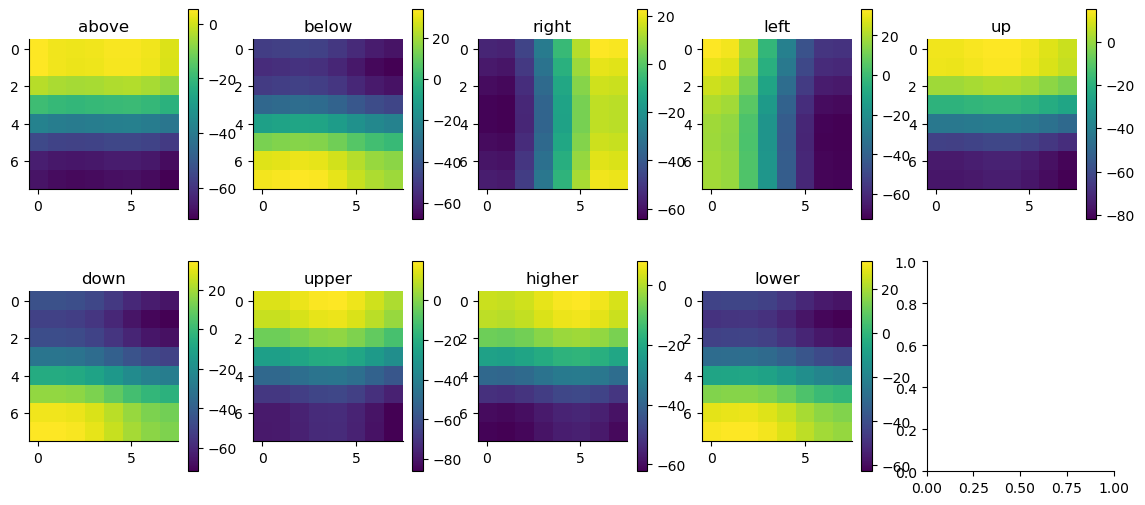

In [47]:
figh, axs = plt.subplots(2, 5, figsize=(14, 6)) 
axs = axs.flatten() 
for i_word in range(len(relation_words)): 
    plt.sca(axs[i_word]) 
    attn_scores_per_word = inner_prod_mat.float()[:, i_word:i_word+1] 
    plt.imshow(attn_scores_per_word.view(8, 8).detach().cpu().numpy()) 
    plt.title(relation_words[i_word]) 
    plt.colorbar() 

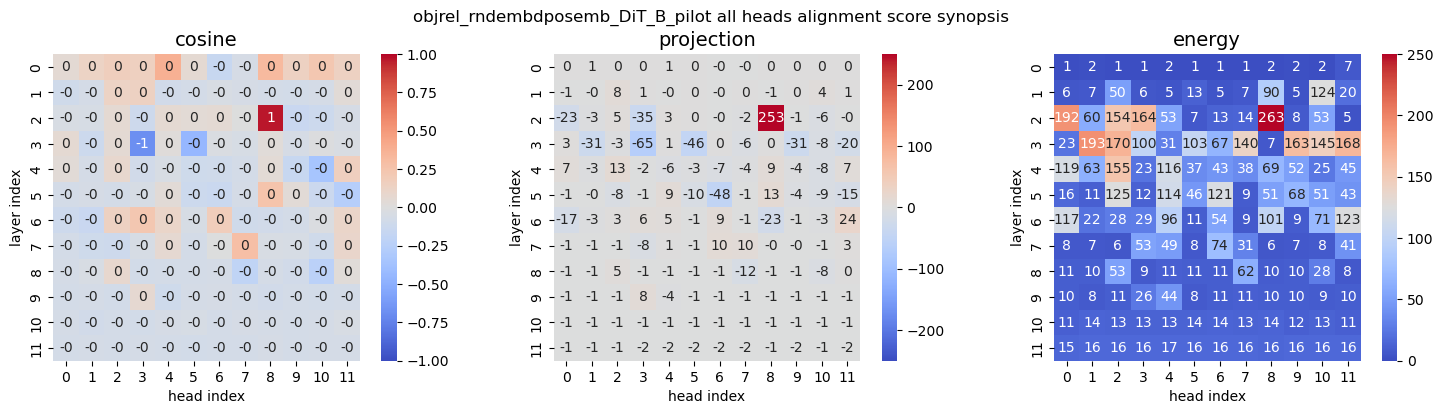

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
figdir = "/n/home12/binxuwang/Github/DiffusionObjectRelation/Figures/DiT_rndpos_attn_head_finding"
align_df_allheads.to_csv(join(figdir, f"{model_run_name}_all_heads_align_df.csv"), index=False)
head_align_synopsis = align_df_allheads.groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)
# Plot each column in head_align_synopsis as a heatmap (layers x heads)
metrics = ["cosine", "projection", "energy", ]
n_metrics = len(metrics)
fig, axes = plt.subplots(1, n_metrics, figsize=(5*n_metrics, 4), squeeze=False)
for idx, metric, clim, fmt in zip(range(n_metrics), metrics, 
                                  [(-1, 1), (-250, 250), (0, 250)], 
                                  [".0f", ".0f", ".0f"]):
    # reshape values into 2D (layer, head)
    heatmap_data = head_align_synopsis[metric].unstack(level="head_idx")
    ax = axes[0, idx]
    sns.heatmap(heatmap_data, annot=True, fmt=fmt, cmap="coolwarm", ax=ax, cbar=True, vmin=clim[0], vmax=clim[1])
    ax.set_aspect("equal")
    ax.set_title(metric, fontsize=14)
    ax.set_xlabel("head index")
    ax.set_ylabel("layer index")
plt.suptitle(f"{model_run_name} all heads alignment score synopsis")
plt.tight_layout()
saveallforms(figdir, f"{model_run_name}_all_heads_align_score_synopsis")
plt.show()